

For this project, you will 

- Step 0: Choose your Language for this Adventure

- Step 1: Find a Story

- Step 2: Remember your Audience

- Step 3: Find and Stage Your Data

- Step 4: Vet Data Sources

- Step 5: Filter Results and Build/Validate Models

- Step 6: Visualize Results

- Step 7: Communicate the Story to your intended audience using visualizations and narratives

---
Here are some recommendations for managing the scope and quality of this project:

- Narrow down the issue, problem, question, or hypothesis for you data story to a single, relatively simple perspective.

- Identify already available data that affords addressing your problem.  If using completely new data, know it well.

- Address the data relative to the statistical/machine learning model(s) chosen to minimize any issues.

- Internally document your code using comments that explain the purpose of the operation(s).


Make your project unique by

- Comparing two or more different statistical/machine learning models using the same data.
- Refrain from identically replicating any existing projects obtained from external sources.
- Running a single model multiple times and changing a different single parameter each time for comparison.
- Changing the sampling proportions for building the hold-out data and comparing the same model performance repeatedly.
- Select something you find interesting or unique in the data and write a story around it.




## Step 0: Choose your Language for this Adventure:

You can do this project in either *R* or *Python*.

To change the kernel of this notebook, do the following with the `Kernel` menu.

 * `Kernel > Change Kernel > Python 3`
 * `Kernel > Change Kernel > R`


`Python 3`

---
## Step 1: Find a Story

Think back to any of the data files we have used in this class. 
Alternatively, you can search online for potential data and story ideas.

In the cell below, please detail the source of your data (with link).
Additionally, preview the story you hope to uncover.

Strokes are caused by blocked blood flow to the brain (ischemic stroke) or sudden bleeding in the brain (hemorrhagic stroke). Many things raise your risk of stroke. Some of these risk factors can be changed to help prevent a stroke or future strokes.

Factors that can control account for 82% to 90% of all strokes:
- High blood pressure
- Obesity
- Physical inactivity
- Poor diet
- Smoking

Other risk factors are based on lifestyle, genetics, and environment.

**Age**, the risk is higher for babies under the age of 1 and for adults as they grow older.\
**Anxiety, depression, and high stress levels**, as well as working long hours and not having much contact with family, friends, or others outside the home, may raise your risk for stroke.\
**Family history and genetics** play a role as well. Your risk of having a stroke is higher if a parent or other family member has had a stroke, particularly at a younger age. Certain genes affect your stroke risk, including those that determine your blood type. People with blood type AB (which is not common) have a higher risk.\
**Living or working in areas with air pollution** can also contribute to stroke risk.\
**Other medical conditions**, such as sleep apnea, kidney disease, and migraine headaches, are also factors.\
**Other unhealthy lifestyle habits**, including drinking too much alcohol, getting too much sleep (more than 9 hours), and using illegal drugs such as cocaine, may raise stroke risk.\
**Race and ethnicity** is another factor. In the United States, stroke occurs more often in Black, Alaska Native, American Indian, and Hispanic adults than in white adults.\
**Sex** can play a role in risk for stroke. At younger ages, men are more likely than women to have a stroke. But women tend to live longer, so their lifetime risk of having a stroke is higher. Women who take birth control pills or use hormone replacement therapy are at higher risk. Women are also at higher risk during pregnancy and in the weeks after giving birth. High blood pressure during pregnancy — such as from preeclampsia — raises the risk of stroke later in life.\
**Viral infections or conditions**, such as lupus or rheumatoid arthritis, can cause inflammation.

Information link : https://www.nhlbi.nih.gov/health/stroke/causes

## Step 2: Remember your Audience

In the cell below, describe your audience!
 * Who will the audience be?
 * What value will they derive from your story?

The audience for this story could be a wide range of individuals including healthcare professionals, policymakers, or even the general public interested in understanding the risks associated with strokes. They would derive value from your story as it could provide insights into the factors contributing to strokes, which could in turn guide prevention measures or policy recommendations.

## Step 3: Find and Stage Your Data

Explain your data in the cell below.

According to the World Health Organization (WHO) stroke is the 2nd leading cause of death globally, responsible for approximately 11% of total deaths.\
The data is from a Kaggle dataset which likely contains several features that could help in understanding or predicting stroke occurrences. It is used to predict whether a patient is likely to get stroke based on the input parameters like gender, age, various diseases, and smoking status. Each row in the data provides relavant information about the patient.
data link: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset


**Attribute Information**
1) id: unique identifier
2) gender: "Male", "Female" or "Other"
3) age: age of the patient
4) hypertension: 0 if the patient doesn't have hypertension, 1 if the patient has hypertension
5) heart_disease: 0 if the patient doesn't have any heart diseases, 1 if the patient has a heart disease
6) ever_married: "No" or "Yes"
7) work_type: "children", "Govt_jov", "Never_worked", "Private" or "Self-employed"
8) Residence_type: "Rural" or "Urban"
9) avg_glucose_level: average glucose level in blood
10) bmi: body mass index
11) smoking_status: "formerly smoked", "never smoked", "smokes" or "Unknown"*
12) stroke: 1 if the patient had a stroke or 0 if not

*Note: "Unknown" in smoking_status means that the information is unavailable for this patient*

## Step 4: Vet Data Sources

Use the cells below to load the data, inspect it, conduct data carpentry and shaping; perform exploratory data analysis.  

Add more cells (`Insert > Insert Cell Below`) if you want additional cells.

In [1]:
import pandas as pd
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict

In [2]:
stroke_data = pd.read_csv('healthcare-dataset-stroke-data.csv')
stroke_data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
stroke_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [4]:
# cut useless column
stroke_data = stroke_data.drop('id',axis=1)
stroke_data.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
# get_dummies
stroke_data_encoded = pd.get_dummies(stroke_data, columns=['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'],drop_first=True)
stroke_data_encoded.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,1,0,1,0,1,0,0,1,1,0,0
1,61.0,0,0,202.21,NaN,1,0,0,1,0,0,1,0,0,0,1,0
2,80.0,0,1,105.92,32.5,1,1,0,1,0,1,0,0,0,0,1,0
3,49.0,0,0,171.23,34.4,1,0,0,1,0,1,0,0,1,0,0,1
4,79.0,1,0,174.12,24.0,1,0,0,1,0,0,1,0,0,0,1,0


In [6]:
# Check for missing values in the dataset
stroke_data_encoded.isnull().sum() #make it percentage if more than 50% clean if not than 50% cut

age                                 0
hypertension                        0
heart_disease                       0
avg_glucose_level                   0
bmi                               201
stroke                              0
gender_Male                         0
gender_Other                        0
ever_married_Yes                    0
work_type_Never_worked              0
work_type_Private                   0
work_type_Self-employed             0
work_type_children                  0
Residence_type_Urban                0
smoking_status_formerly smoked      0
smoking_status_never smoked         0
smoking_status_smokes               0
dtype: int64

In [7]:
#fillna
stroke_data_encoded.bmi = stroke_data_encoded.bmi.fillna(stroke_data_encoded.bmi.mean()) 

In [8]:
stroke_data_encoded.isnull().sum()

age                               0
hypertension                      0
heart_disease                     0
avg_glucose_level                 0
bmi                               0
stroke                            0
gender_Male                       0
gender_Other                      0
ever_married_Yes                  0
work_type_Never_worked            0
work_type_Private                 0
work_type_Self-employed           0
work_type_children                0
Residence_type_Urban              0
smoking_status_formerly smoked    0
smoking_status_never smoked       0
smoking_status_smokes             0
dtype: int64

In [9]:
#split
X = stroke_data_encoded.drop('stroke', axis=1)
y = stroke_data_encoded['stroke']
y = y.astype('int')

from sklearn.model_selection import train_test_split
X_trainx, X_testx, y_trainx, y_testx = train_test_split(X, y, test_size=0.2, random_state=1)

In [10]:
#feature selection
scaler = StandardScaler()
scaler.fit(X_trainx) 
X_train_sc = scaler.transform(X_trainx)
X_train_sc = pd.DataFrame(X_train_sc, columns=X_trainx.columns)
X_train_sc.std(numeric_only=True)
X_test_sc = scaler.transform(X_testx)
X_test_sc = pd.DataFrame(X_test_sc, columns=X_testx.columns)
X_test_sc.std(numeric_only=True)

age                               0.999386
hypertension                      1.013884
heart_disease                     0.987642
avg_glucose_level                 0.997144
bmi                               1.013101
gender_Male                       0.992562
gender_Other                      0.031281
ever_married_Yes                  1.002678
work_type_Never_worked            0.795792
work_type_Private                 0.995058
work_type_Self-employed           0.988689
work_type_children                0.947955
Residence_type_Urban              1.000534
smoking_status_formerly smoked    0.989255
smoking_status_never smoked       1.011254
smoking_status_smokes             1.010809
dtype: float64

In [11]:
# cut gender_Other 
stroke_data_encoded = stroke_data_encoded.drop('gender_Other', axis=1)
stroke_data_encoded.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.600000,1,1,1,0,1,0,0,1,1,0,0
1,61.0,0,0,202.21,28.893237,1,0,1,0,0,1,0,0,0,1,0
2,80.0,0,1,105.92,32.500000,1,1,1,0,1,0,0,0,0,1,0
3,49.0,0,0,171.23,34.400000,1,0,1,0,1,0,0,1,0,0,1
4,79.0,1,0,174.12,24.000000,1,0,1,0,0,1,0,0,0,1,0


In [12]:
stroke_data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             5110 non-null   float64
 1   hypertension                    5110 non-null   int64  
 2   heart_disease                   5110 non-null   int64  
 3   avg_glucose_level               5110 non-null   float64
 4   bmi                             5110 non-null   float64
 5   stroke                          5110 non-null   int64  
 6   gender_Male                     5110 non-null   uint8  
 7   ever_married_Yes                5110 non-null   uint8  
 8   work_type_Never_worked          5110 non-null   uint8  
 9   work_type_Private               5110 non-null   uint8  
 10  work_type_Self-employed         5110 non-null   uint8  
 11  work_type_children              5110 non-null   uint8  
 12  Residence_type_Urban            51

In [13]:
# change type of data to category
stroke_data_encoded = stroke_data_encoded.astype({
    'hypertension': 'category',
    'heart_disease':'category', 
    'stroke': 'category',
    'gender_Male':'category', 
    'ever_married_Yes': 'category',
    'work_type_Never_worked': 'category', 
    'work_type_Private': 'category', 
    'work_type_Self-employed': 'category', 
    'work_type_children': 'category', 
    'Residence_type_Urban': 'category', 
    'smoking_status_formerly smoked': 'category', 
    'smoking_status_never smoked': 'category', 
    'smoking_status_smokes': 'category'})
stroke_data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   age                             5110 non-null   float64 
 1   hypertension                    5110 non-null   category
 2   heart_disease                   5110 non-null   category
 3   avg_glucose_level               5110 non-null   float64 
 4   bmi                             5110 non-null   float64 
 5   stroke                          5110 non-null   category
 6   gender_Male                     5110 non-null   category
 7   ever_married_Yes                5110 non-null   category
 8   work_type_Never_worked          5110 non-null   category
 9   work_type_Private               5110 non-null   category
 10  work_type_Self-employed         5110 non-null   category
 11  work_type_children              5110 non-null   category
 12  Residence_type_Urban

In [14]:
#train test split
X = stroke_data_encoded.drop('stroke', axis=1)
y = stroke_data_encoded['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [15]:
# check balance data
from collections import Counter
print(' dataset shape %s' % Counter(y))

 dataset shape Counter({0: 4861, 1: 249})


In [16]:
# preprocessor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['category']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), num_cols), # fill any missing values in the numerical columns with the mean value
        ('cat', Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore')) 
        #  OneHotEncoder to convert the categorical variables into a format suitable for machine learning algorithms and ignore unknown categories
        ]), cat_cols)])

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

In [17]:
#fix data imbalance problem by use SMOTE
from imblearn.over_sampling import SMOTE
sm = SMOTE(sampling_strategy='minority', random_state=42)
oversampled_X, oversampled_y = sm.fit_resample(X_train_preprocessed, y_train)
oversampled = pd.concat([pd.DataFrame(oversampled_y), pd.DataFrame(oversampled_X)], axis=1)
print('SMOTE resampled dataset shape %s' % Counter(oversampled_y))

SMOTE resampled dataset shape Counter({0: 3889, 1: 3889})


## Step 5: Filter Results and Build and Validate Models


Perform any additional data carpentry and begin filtering results/data and then build, validate, and describe your model(s). 

Add more cells (`Insert > Insert Cell Below`) if you want additional cells.

In [18]:
# decision tree prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
clf = DecisionTreeClassifier()
clf = clf.fit(oversampled_X,oversampled_y)
y_pred = clf.predict(X_test_preprocessed)
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.9031311154598826


In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report
from imblearn.metrics import specificity_score
class_dt = classification_report(y_test,y_pred,output_dict=True)
df_dt = pd.DataFrame(class_dt)
print(df_dt)

                    0          1  accuracy    macro avg  weighted avg
precision    0.956113   0.123077  0.903131     0.539595      0.915358
recall       0.941358   0.160000  0.903131     0.550679      0.903131
f1-score     0.948678   0.139130  0.903131     0.543904      0.909072
support    972.000000  50.000000  0.903131  1022.000000   1022.000000


In [20]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=5000, random_state=42)
lr.fit(oversampled_X, oversampled_y)
lr_predictions = lr.predict(X_test_preprocessed)
print("Accuracy:",metrics.accuracy_score(y_test, lr_predictions))

Accuracy: 0.7690802348336595


In [21]:
class_lr = classification_report(y_test,lr_predictions,output_dict=True)
df_lr = pd.DataFrame(class_lr)
print(df_lr)

                    0          1  accuracy    macro avg  weighted avg
precision    0.981675   0.139535   0.76908     0.560605      0.940475
recall       0.771605   0.720000   0.76908     0.745802      0.769080
f1-score     0.864055   0.233766   0.76908     0.548911      0.833219
support    972.000000  50.000000   0.76908  1022.000000   1022.000000


In [22]:
# RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(bootstrap=True, min_samples_leaf=1, min_samples_split=2)
rf.fit(oversampled_X, oversampled_y)
rf_predictions = rf.predict(X_test_preprocessed)
print("Accuracy:",metrics.accuracy_score(y_test, rf_predictions))

Accuracy: 0.9403131115459883


In [23]:
class_rf = classification_report(y_test,rf_predictions,output_dict=True)
df_rf = pd.DataFrame(class_rf)
print(df_rf)

                    0          1  accuracy    macro avg  weighted avg
precision    0.952334   0.133333  0.940313     0.542833      0.912265
recall       0.986626   0.040000  0.940313     0.513313      0.940313
f1-score     0.969176   0.061538  0.940313     0.515357      0.924771
support    972.000000  50.000000  0.940313  1022.000000   1022.000000


In [24]:
result_data = pd.concat([df_dt.drop('support', axis=0),df_lr.drop('support', axis=0),df_rf.drop('support', axis=0)], keys = ['Decision Tree','Logistic Regression','Random Forest'])
result_data

0         1  accuracy  macro avg  \
Decision Tree       precision  0.956113  0.123077  0.903131   0.539595   
                    recall     0.941358  0.160000  0.903131   0.550679   
                    f1-score   0.948678  0.139130  0.903131   0.543904   
Logistic Regression precision  0.981675  0.139535  0.769080   0.560605   
                    recall     0.771605  0.720000  0.769080   0.745802   
                    f1-score   0.864055  0.233766  0.769080   0.548911   
Random Forest       precision  0.952334  0.133333  0.940313   0.542833   
                    recall     0.986626  0.040000  0.940313   0.513313   
                    f1-score   0.969176  0.061538  0.940313   0.515357   

                               weighted avg  
Decision Tree       precision      0.915358  
                    recall         0.903131  
                    f1-score       0.909072  
Logistic Regression precision      0.940475  
                    recall         0.769080  
                    f1-score       0.833219  
Random Forest       precision      0.912265  
                    recall         0.940313  
                    f1-score       0.924771

## Step 6: Visualize Results

Build up your key visual story elements!

Add more cells (`Insert > Insert Cell Below`) if you want additional cells.

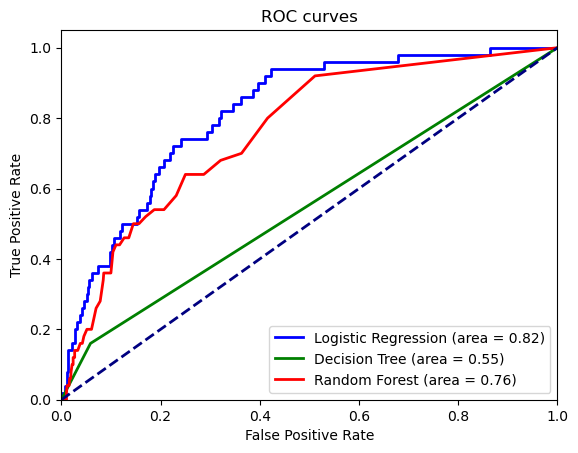

In [25]:
from sklearn.metrics import roc_curve, auc

# For Logistic Regression
y_score_lr = lr.predict_proba(X_test_preprocessed)[:,1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_score_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# For Decision Tree
y_score_dt = clf.predict_proba(X_test_preprocessed)[:,1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_score_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# For Random Forest
y_score_rf = rf.predict_proba(X_test_preprocessed)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_score_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plotting the ROC curves
plt.figure()
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label='Logistic Regression (area = %0.2f)' % roc_auc_lr)
plt.plot(fpr_dt, tpr_dt, color='green', lw=2, label='Decision Tree (area = %0.2f)' % roc_auc_dt)
plt.plot(fpr_rf, tpr_rf, color='red', lw=2, label='Random Forest (area = %0.2f)' % roc_auc_rf)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves')
plt.legend(loc="lower right")
plt.show()

In [26]:
#statistic test
auc_lr = roc_auc_score(y_test, y_score_lr)
auc_dt = roc_auc_score(y_test, y_score_dt)
auc_rf = roc_auc_score(y_test, y_score_rf)
print(f'AUC: LR: {auc_lr:.2f}, DT: {auc_dt:.2f}, RF: {auc_rf:.2f}')

,Decision Tree,Logistic Regression,Random Forest
Decision Tree,1.000000e+00,0.000000e+00,5.670578e-93
Logistic Regression,0.000000e+00,1.000000e+00,8.442416e-225
Random Forest,5.670578e-93,8.442416e-225,1.000000e+00


## Step 7: Communicate the Story to your intended audience using visualizations and narrative


In a few paragraphs, describe the story the data tells. 

**ROC-AUC Curve**

ROC - Receiver Operating Characteristic Curve เป็นเส้นที่ใช้วัดถึงประสิทธิภาพของโมเดลแบบ Classification\
AUC - Area Under ROC Curve หรือพื้นที่ใต้กราฟ ROC\
สิ่งที่ต้องการคือ True Positive Rate มาก(model ทำนายถูกต้องมาก) และค่า False Positive Rate ต่ำ\
ซึ่งจะสามารถทราบความแม่นยำได้จากค่า AUC\
จากกราฟจะพบว่า Logistic Regression มีค่า AUC สูงที่สุด จึงสามารถใช้ Model นี้ในการทำนายโรค Stroke จากข้อมูลชุดนี้ได้ดีที่สุด เมื่อเทียบกับ Decision Tree และ Random Forest ซึ่งเมื่อดูค่า p-values จะพบว่า Model ทั้งสามนั้นแตกต่างกันอย่างมีนัยสำคัญทางสถิติ









